# Custom satellite kernel with wis

wis ships built-in `KernelSpecifier` objects for common spacecraft (TESS, Gaia, JWST, etc.). When you need a spacecraft that is not yet supported, you can supply a *custom* specifier that allows you to interact with BSP files through a unified interface. This notebook walks through two workflows related to that: creating a `KernelSpecifier` from an online source, and creating one from a local file.

In [3]:
from __future__ import annotations

%matplotlib inline

import csv
from datetime import timedelta
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import requests
import spiceypy as sp
from astropy.time import Time, TimeDelta
from wis.kernels import DE430, DE440
from wis.kernelspecifier import KernelSpecifier

from wis import Wis

# Option 1: Obtain a BSP file from an online source

`Wis` ships with `KernelSpecifier` objects for HST and TESS, but to demonstrate how to create a custom kernel, we'll pretend temporarily that it didn't.

[Text(0.5, 0, 'X [km]'),
 Text(0, 0.5, 'Y [km]'),
 Text(0.5, 1.0, 'HST Geocentric Orbit'),
 None]

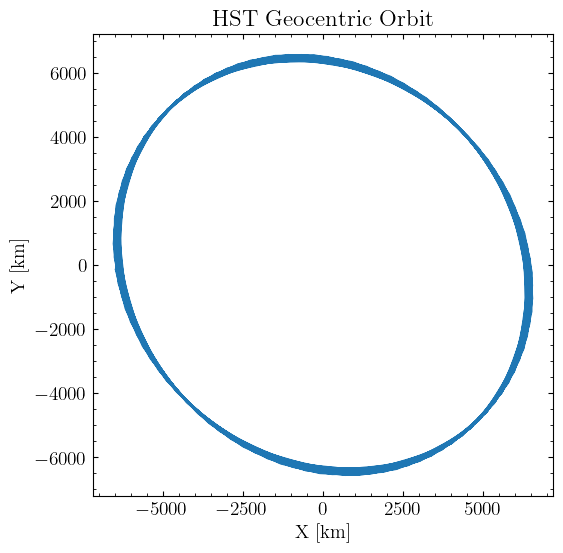

In [13]:
# Create the KernelSpecifier
hst_kernel = KernelSpecifier(
    obscodeMPC="250",
    obscodeJPL="-48",
    name="HST",
    files=[
        "https://naif.jpl.nasa.gov/pub/naif/HST/kernels/spk/hst.bsp",
    ],
    wildcards={},
    timecritical=[
        "https://naif.jpl.nasa.gov/pub/naif/HST/kernels/spk/hst.bsp",
    ],
)

times = Time("2026-01-01") + np.linspace(0, 2, 1000) * u.day

with Wis(kernels=[DE440, hst_kernel]) as w:
    # Barycentric positions (SSB = origin) [AU]
    hst_bary = w.get_obs_bary_equ_AU("250", times)
    earth_bary = w.get_obs_bary_equ_AU("500", times)

    # HST geocentric position [AU]
    hst_geo = (hst_bary - earth_bary) * u.AU.to(u.km)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(hst_geo[:, 0], hst_geo[:, 1], label="HST")
ax.set(xlabel="X [km]", ylabel="Y [km]", title="HST Geocentric Orbit", aspect="equal")

In the cell above, note that we just provided the URLs to the ephemeris kernels, and marked some of them "timecritical" so that `Wis` would know to update them even if they'd been previously downloaded. We could also use the "wildcard" field if we didn't want to specify the exact filenames: for example, that's what the built-in `KernelSpecifier` for TESS does:

```python
TESS = KernelSpecifier(
    obscodeMPC="C57",
    obscodeJPL="-95",
    name="TESS",
    files=[],
    wildcards={"https://archive.stsci.edu/missions/tess/models/": "TESS_EPH_DEF*"},
)
```

# Option 2: Use a local BSP file

Now let's say you have a local BSP file for a spacecraft that is not yet supported by `Wis`. You can create a `KernelSpecifier` that points to that file, and then use it to query positions as usual.

### Step 1 — Obtain a BSP file (tutorial shim)

> **Note:** The code in this section is a *quick shim* for generating a local BSP from JPL
> Horizons.  It is not a recommended production approach — in practice you would obtain an
> official kernel from [NAIF](https://naif.jpl.nasa.gov/naif/data.html), a mission archive,
> or a dedicated tool.  The shim exists solely to give this tutorial a self-contained BSP
> to work with.

Horizons returns state vectors (position + velocity in km and km/s) as CSV.
`spiceypy.spkw13` packages them into a *type-13 Hermite SPK*, the format SPICE expects.

In [2]:
HORIZONS_API_URL = "https://ssd.jpl.nasa.gov/api/horizons.api"
SOLAR_SYSTEM_BARYCENTER_ID = 0
J2000_TDB_JD = 2451545.0
SECONDS_PER_DAY = 86400.0


def _query_horizons_vectors(
    *,
    naif_id: int,
    start_time: str,
    end_time: str,
    sampling_cadence: str,
    center_id: int,
    timeout_seconds: float,
) -> tuple[np.ndarray, np.ndarray]:
    params = {
        "format": "text",
        "COMMAND": f"'{naif_id}'",
        "OBJ_DATA": "'NO'",
        "MAKE_EPHEM": "'YES'",
        "EPHEM_TYPE": "'VECTORS'",
        "CENTER": f"'@{center_id}'",
        "START_TIME": f"'{start_time}'",
        "STOP_TIME": f"'{end_time}'",
        "STEP_SIZE": f"'{sampling_cadence}'",
        "REF_PLANE": "'FRAME'",
        "REF_SYSTEM": "'ICRF'",
        "OUT_UNITS": "'KM-S'",
        "VEC_TABLE": "'3'",
        "CSV_FORMAT": "'YES'",
    }
    response = requests.get(HORIZONS_API_URL, params=params, timeout=timeout_seconds)
    response.raise_for_status()
    text = response.text

    if "$$SOE" not in text or "$$EOE" not in text:
        raise RuntimeError(f"Horizons did not return vector data:\n{text}")

    rows = text.split("$$SOE", maxsplit=1)[1].split("$$EOE", maxsplit=1)[0]
    jd_values: list[float] = []
    state_values: list[list[float]] = []
    for row in csv.reader(line for line in rows.splitlines() if line.strip()):
        jd_values.append(float(row[0]))
        state_values.append([float(v) for v in row[2:8]])

    if len(jd_values) < 2:
        raise RuntimeError("Horizons returned fewer than two vector states")

    return (
        np.asarray(jd_values, dtype=np.float64),
        np.asarray(state_values, dtype=np.float64),
    )


def _format_time(time: str | Time) -> str:
    if isinstance(time, Time):
        if not time.isscalar:
            raise ValueError("start_time and end_time must be scalar Time objects")
        return time.tdb.iso
    return time


def _format_cadence(cadence: str | timedelta | TimeDelta) -> str:
    if isinstance(cadence, str):
        return cadence
    seconds = (
        float(cadence.to_value("s"))
        if isinstance(cadence, TimeDelta)
        else cadence.total_seconds()
    )
    if seconds <= 0.0:
        raise ValueError("sampling_cadence must be positive")
    for unit_seconds, unit_name in (
        (SECONDS_PER_DAY, "d"),
        (3600.0, "h"),
        (60.0, "min"),
    ):
        value = seconds / unit_seconds
        if value.is_integer():
            return f"{int(value)} {unit_name}"
    return f"{seconds:g} seconds"


def _valid_type13_degree(requested_degree: int, n_states: int) -> int:
    if requested_degree < 1:
        raise ValueError("interpolation_degree must be positive")
    degree = min(requested_degree, n_states - 1)
    if degree % 2 == 0:
        degree -= 1
    if degree < 1:
        raise RuntimeError("Need at least two Horizons states to write an SPK")
    return degree

In [3]:
def create_bsp_from_horizons(
    naif_id: int,
    start_time: str | Time,
    end_time: str | Time,
    sampling_cadence: str | timedelta | TimeDelta,
    output_path: str | Path = "horizons.bsp",
    *,
    overwrite: bool = False,
    center_id: int = SOLAR_SYSTEM_BARYCENTER_ID,
    interpolation_degree: int = 7,
    timeout_seconds: float = 120.0,
) -> Path:
    """Query Horizons and write a type-13 SPK/BSP for the given NAIF body ID.

    Args:
        naif_id: NAIF integer ID of the target body (e.g. -33 for NEO Surveyor).
        start_time: Horizons-compatible start time, e.g. "2028-Jan-01",
            or a scalar astropy.time.Time.
        end_time: Horizons-compatible end time, or a scalar astropy.time.Time.
        sampling_cadence: Step size, e.g. "6 h" or "1 d".
            datetime.timedelta and astropy.time.TimeDelta are converted automatically.
        output_path: BSP path to write.
        overwrite: Replace an existing file when True.
        center_id: NAIF ID of the SPK segment center. Defaults to 0 (SSB).
        interpolation_degree: Type-13 Hermite polynomial degree.
        timeout_seconds: Network timeout for the Horizons API request.

    Returns:
        The written BSP path.
    """
    output = Path(output_path).expanduser().resolve()
    if output.exists():
        if not overwrite:
            raise FileExistsError(
                f"{output} already exists; pass overwrite=True to replace it"
            )
        output.unlink()
    output.parent.mkdir(parents=True, exist_ok=True)

    jd_tdb, states_km_s = _query_horizons_vectors(
        naif_id=naif_id,
        start_time=_format_time(start_time),
        end_time=_format_time(end_time),
        sampling_cadence=_format_cadence(sampling_cadence),
        center_id=center_id,
        timeout_seconds=timeout_seconds,
    )
    epochs_et = (jd_tdb - J2000_TDB_JD) * SECONDS_PER_DAY
    degree = _valid_type13_degree(interpolation_degree, len(epochs_et))

    handle = sp.spkopn(str(output), f"NAIF-{naif_id} Horizons states", 0)
    try:
        sp.spkw13(
            handle,
            naif_id,
            center_id,
            "J2000",
            float(epochs_et[0]),
            float(epochs_et[-1]),
            f"HORIZONS_{naif_id}_{center_id}",
            degree,
            len(epochs_et),
            states_km_s,
            epochs_et,
        )
    finally:
        sp.spkcls(handle)

    return output

With the helpers defined, create a BSP covering three years at daily cadence:

In [ ]:
bsp_path = create_bsp_from_horizons(
    naif_id=-33,
    start_time="2028-Jan-01",
    end_time="2031-Jan-01",
    sampling_cadence="1 d",
    output_path="neo_surveyor.bsp",
    overwrite=True,
)
print(f"Wrote: {bsp_path}")

### Step 2 — Wrap the BSP in a `KernelSpecifier`

`KernelSpecifier` normally manages downloading remote kernel files from the web.
For a local BSP the download machinery is not needed, but two requirements still apply:

1. The pydantic validator requires at least one entry in `files` or `wildcards`.
   We satisfy it by passing a `file://` URI of the local path.
2. `load()` iterates over the *keys* of `kernel_filepath_map` and furnishes them
   with SPICE.  We bypass the normal download step by setting `kernel_filepath_map`
   directly, with the resolved local path as the key.

In [5]:
def local_kernel_specifier(
    *,
    obscodeMPC: str,
    obscodeJPL: str,
    name: str,
    path: str | Path,
) -> KernelSpecifier:
    """Build a KernelSpecifier for a local BSP, skipping the download machinery."""
    resolved = Path(path).expanduser().resolve()
    if not resolved.exists():
        raise FileNotFoundError(f"{name} kernel not found: {resolved}")
    uri = resolved.as_uri()
    kernel = KernelSpecifier(
        obscodeMPC=obscodeMPC,
        obscodeJPL=obscodeJPL,
        name=name,
        files=[uri],
        wildcards={},
    )
    kernel.kernel_filepath_map = {str(resolved): uri}
    return kernel

In [6]:
neo_surveyor = local_kernel_specifier(
    obscodeMPC="C58",
    obscodeJPL="-33",
    name="NEO Surveyor",
    path=bsp_path,
)

### Step 3 — Query positions with `Wis`

Pass the custom specifier alongside `DE430`.  We use two time grids: a coarse annual grid
for the solar-system-scale view and a finer two-month grid for the orbital-scale view.

In [7]:
# 3-year daily grid matching the BSP coverage
times = Time("2028-01-01") + np.arange(1096) * u.day

with Wis(kernels=[DE430, neo_surveyor]) as w:
    # Barycentric positions (SSB = origin) [AU]
    neos_bary = w.get_obs_bary_equ_AU("C58", times)
    earth_bary = w.get_obs_bary_equ_AU("500", times)

    # Heliocentric positions for geocentric difference
    neos_helio, _ = w.get_obs_helio_equ_AU("C58", times)
    earth_helio, _ = w.get_obs_helio_equ_AU("500", times)

# NEO Surveyor geocentric position [AU]
neos_geo = neos_helio - earth_helio

/Users/cassese/Documents/Work/Code/mpc-software/.venv/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 731 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


### Barycentric (SSB) frame

In the barycentric frame the origin is the solar-system barycenter.  NEO Surveyor orbits
near 1 AU like Earth, so the two paths are similar in scale — differences become visible
only at smaller scales.

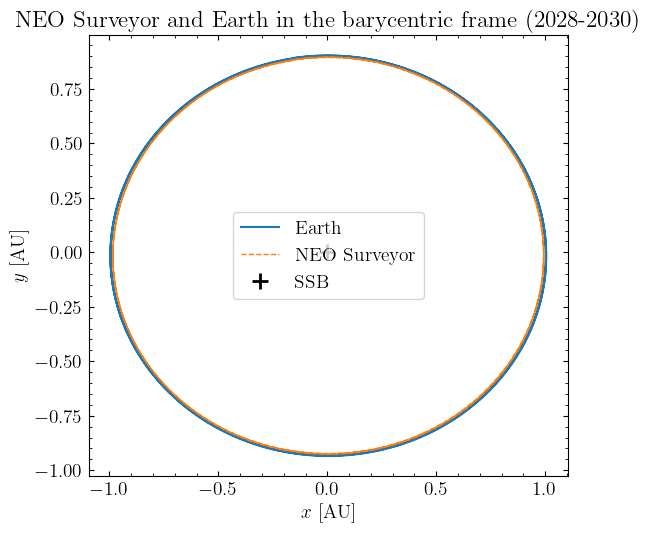

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(earth_bary[:, 0], earth_bary[:, 1], lw=1.5, label="Earth")
ax.plot(neos_bary[:, 0], neos_bary[:, 1], lw=1, ls="--", label="NEO Surveyor")
ax.plot(0, 0, "k+", ms=12, mew=2, label="SSB", zorder=5)

ax.set_xlabel(r"$x$ [AU]")
ax.set_ylabel(r"$y$ [AU]")
ax.set_aspect("equal")
ax.legend()
ax.set_title("NEO Surveyor and Earth in the barycentric frame (2028-2030)")
plt.tight_layout()
plt.show()

### Geocentric frame

Centering on Earth reveals NEO Surveyor's position relative to Earth.  The scatter color
encodes elapsed time, showing how the separation evolves over the two-month window.

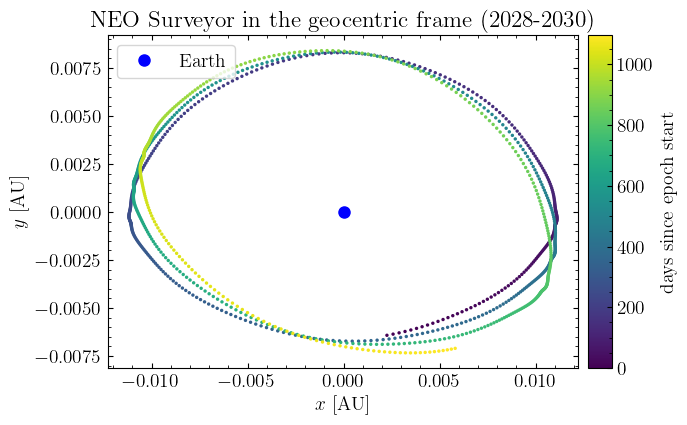

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(
    neos_geo[:, 0],
    neos_geo[:, 1],
    c=np.arange(len(times)),
    cmap="viridis",
    s=6,
    lw=0,
)
ax.plot(0, 0, "bo", ms=8, label="Earth", zorder=5)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(sc, cax=cax, label="days since epoch start")

ax.set_xlabel(r"$x$ [AU]")
ax.set_ylabel(r"$y$ [AU]")
ax.set_aspect("equal")
ax.legend(loc="upper left")
ax.set_title("NEO Surveyor in the geocentric frame (2028-2030)")
plt.tight_layout()
plt.show()

### Summary

The same pattern applies to any spacecraft with a known NAIF ID and an available BSP:
substitute the NAIF ID, MPC code, and time window in the cells above.
For production use, prefer obtaining the BSP from an official source rather than
from the Horizons shim shown here.